<a href="https://colab.research.google.com/github/niha630/Customer_Behavior_Analysis/blob/main/Customer_Behavior_bankdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# ===============================
# Import Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [53]:
# ===============================
# 2. Upload Dataset
# ===============================
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (2).csv


In [54]:
# ===============================
# Load Dataset
# ===============================

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [55]:
# ===============================
# Dataset Info
# ===============================

df.info()

df.describe()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [56]:
# ===============================
# Data Cleaning
# ===============================

df.drop(["RowNumber","CustomerId","Surname"], axis=1, inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [57]:
# ===============================
# Missing Values
# ===============================

df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [58]:
# ===============================
# Encoding
# ===============================

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

print("\nEncoded Dataset")
df.head()


Encoded Dataset


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [59]:
# ===============================
# Churn Rate Analysis
# ===============================

print("Churn Rate:", df["Exited"].mean())

df["Exited"].value_counts()

Churn Rate: 0.2037


,count
Exited,
0,7963
1,2037


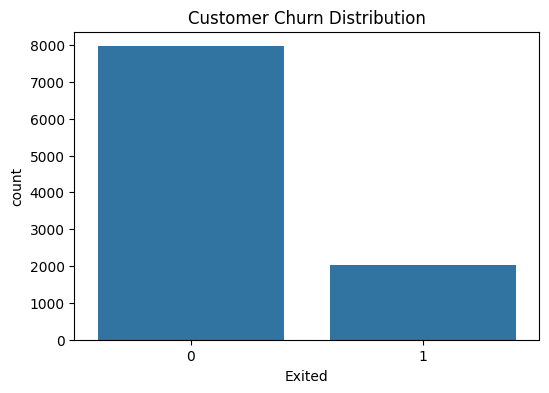

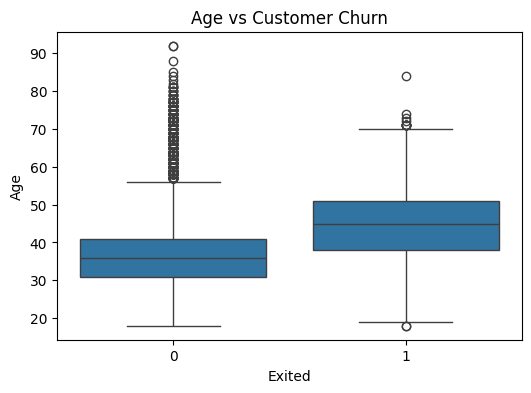

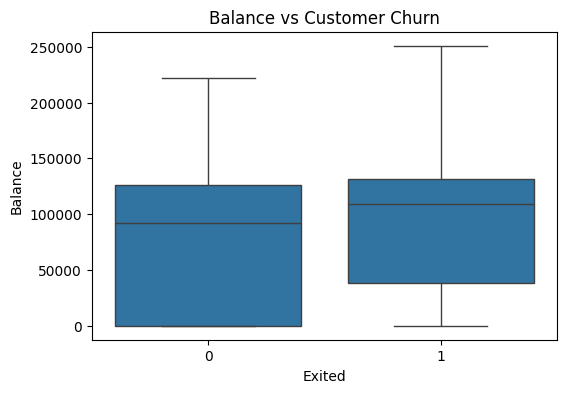

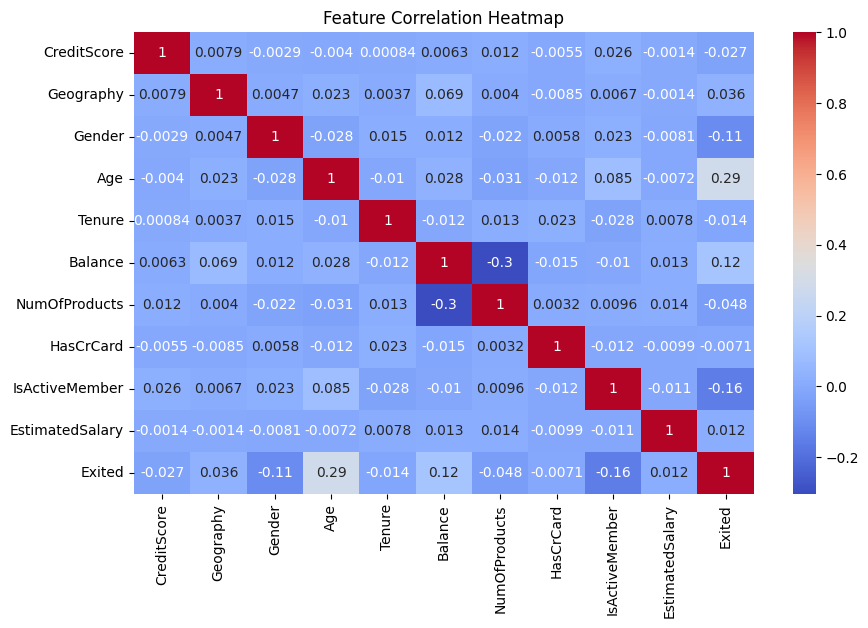

In [60]:
# ===============================
# 6. Exploratory Data Analysis
# ===============================

plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("Age vs Customer Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Balance vs Customer Churn")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [61]:
# ===============================
# Feature Selection
# ===============================

X = df.drop("Exited", axis=1)

y = df["Exited"]

In [62]:
# ===============================
# Train Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
# ===============================
# Feature Scaling
# ===============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [64]:
# ===============================
# 10. Train Models
# ===============================

# Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)


# Decision Tree
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)


# Random Forest
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)


# KNN
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

Logistic Regression Accuracy: 0.8155
Decision Tree Accuracy: 0.7795
Random Forest Accuracy: 0.8675
KNN Accuracy: 0.8355


In [65]:
# ===============================
# Model Comparison
# ===============================
results = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest","KNN"],
    "Accuracy":[acc_lr, acc_dt, acc_rf, acc_knn]
})

print(results)



                 Model  Accuracy
0  Logistic Regression    0.8155
1        Decision Tree    0.7795
2        Random Forest    0.8675
3                  KNN    0.8355


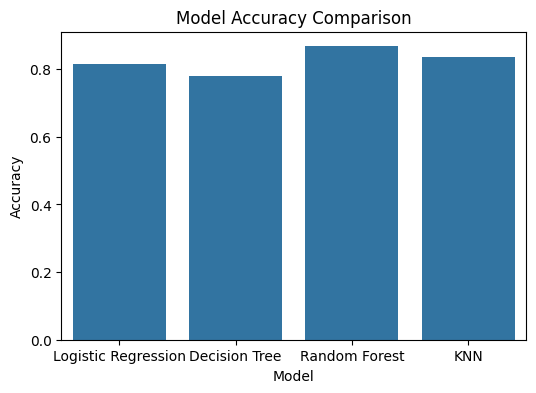

In [66]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.show()

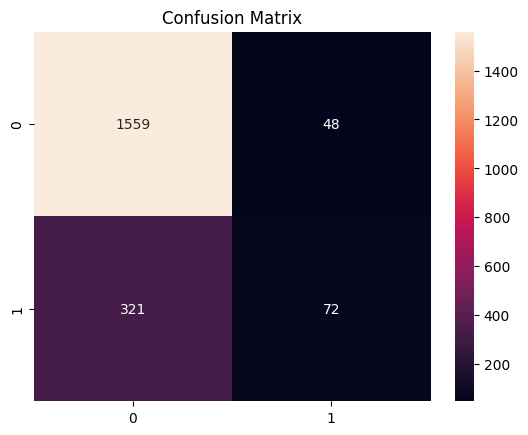

In [67]:
# ===============================
# 12. Confusion Matrix
# ===============================

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.show()

In [68]:
# ===============================
# 13. Precision Recall F1 Score
# ===============================

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



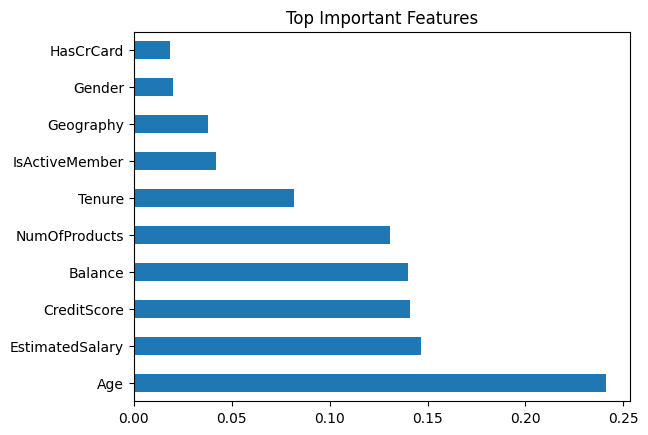

In [69]:
# ===============================
# 14. Feature Importance
# ===============================

importances = rf.feature_importances_

feat_importances = pd.Series(importances, index=X.columns)

feat_importances.nlargest(10).plot(kind="barh")

plt.title("Top Important Features")

plt.show()


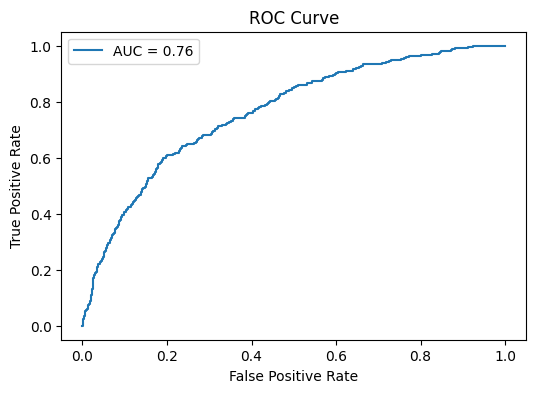

In [70]:
# ===============================
# 15. ROC Curve
# ===============================

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


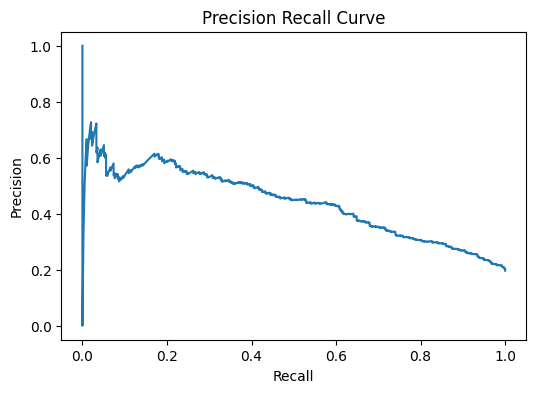

In [71]:
# ===============================
# 16. Precision Recall Curve
# ===============================

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [72]:
# ===============================
# 17. Predict Churn for New Customer
# ===============================

# example customer

new_customer = [[
600, 1, 0, 40, 3, 60000, 2, 1, 1, 50000
]]

new_customer_scaled = scaler.transform(new_customer)

prediction = lr.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Prediction: Customer will exit the bank")
else:
    print("Prediction: Customer will stay")

Prediction: Customer will stay


In [73]:
print("Project Completed Successfully")

Project Completed Successfully
